In [15]:
import requests

# URL de l'API pour lister les indicateurs
api_url_indicators = "http://api.worldbank.org/v2/indicator?format=json&per_page=10000"

# Récupérer les indicateurs
response = requests.get(api_url_indicators)
if response.status_code == 200:
    indicators_data = response.json()[1]  # Le deuxième élément contient la liste des indicateurs
    print(f"Nombre total d'indicateurs disponibles : {len(indicators_data)}")
else:
    print(f"Erreur lors de la récupération des indicateurs : {response.status_code}")
    

Nombre total d'indicateurs disponibles : 10000


In [16]:
import requests
import pandas as pd

# URL de l'API pour lister les indicateurs
api_url_indicators = "http://api.worldbank.org/v2/indicator?format=json&per_page=10000"

# Récupérer les indicateurs
response = requests.get(api_url_indicators)

# Vérifier la réponse
if response.status_code == 200:
    # Récupérer les données JSON (la liste des indicateurs est dans le deuxième élément)
    indicators_data = response.json()[1]
    
    # Convertir les données en DataFrame
    df_indicators = pd.DataFrame(indicators_data)
    
    # Afficher les premières lignes du DataFrame
    print(f"Nombre total d'indicateurs disponibles : {len(df_indicators)}")
    print(df_indicators)  # Afficher les 5 premières lignes du DataFrame
else:
    print(f"Erreur lors de la récupération des indicateurs : {response.status_code}")


Nombre total d'indicateurs disponibles : 10000
                        id                                             name  \
0       1.0.HCount.1.90usd                  Poverty Headcount ($1.90 a day)   
1        1.0.HCount.2.5usd                  Poverty Headcount ($2.50 a day)   
2     1.0.HCount.Mid10to50            Middle Class ($10-50 a day) Headcount   
3          1.0.HCount.Ofcl          Official Moderate Poverty Rate-National   
4      1.0.HCount.Poor4uds                     Poverty Headcount ($4 a day)   
...                    ...                                              ...   
9995        IT.MOB.INVS.CD    Mobile communication investment (current US$)   
9996        IT.MOB.INVS.CN    Mobile communication investment (current LCU)   
9997        IT.MOB.REVN.CD  Revenue from mobile communication (current US$)   
9998        IT.MOB.REVN.CN  Revenue from mobile communication (current LCU)   
9999           IT.NET.BBND                    Fixed broadband subscriptions   

    

In [17]:
# Sélection manuelle d'indicateurs pertinents
indicateurs_selectionnes = {
    "NY.GDP.PCAP.CD": "PIB par habitant (en dollars US courants)",
    "EN.ATM.CO2E.PC": "Émissions de CO₂ (tonnes par habitant)",
    "EG.ELC.ACCS.ZS": "Pourcentage de la population ayant accès à l'électricité",
    "SP.DYN.IMRT.IN": "Taux de mortalité infantile (pour 1 000 naissances vivantes)",
    "SE.ADT.LITR.ZS": "Taux d'alphabétisation chez les adultes"
}

# Afficher les indicateurs sélectionnés
print("Indicateurs sélectionnés pour l'analyse :")
for code, description in indicateurs_selectionnes.items():
    print(f"{code} : {description}")

Indicateurs sélectionnés pour l'analyse :
NY.GDP.PCAP.CD : PIB par habitant (en dollars US courants)
EN.ATM.CO2E.PC : Émissions de CO₂ (tonnes par habitant)
EG.ELC.ACCS.ZS : Pourcentage de la population ayant accès à l'électricité
SP.DYN.IMRT.IN : Taux de mortalité infantile (pour 1 000 naissances vivantes)
SE.ADT.LITR.ZS : Taux d'alphabétisation chez les adultes


In [18]:
import requests
import pandas as pd

# Liste des indicateurs sélectionnés
indicateurs_selectionnes = {
    "NY.GDP.PCAP.CD": "PIB par habitant (en dollars US courants)",
    "EN.ATM.CO2E.PC": "Émissions de CO₂ (tonnes par habitant)",
    "EG.ELC.ACCS.ZS": "Pourcentage de la population ayant accès à l'électricité",
    "SP.DYN.IMRT.IN": "Taux de mortalité infantile (pour 1 000 naissances vivantes)",
    "SE.ADT.LITR.ZS": "Taux d'alphabétisation chez les adultes"
}

# Période pour laquelle récupérer les données
annee_debut = 2010
annee_fin = 2023

# Initialiser un DataFrame vide pour stocker toutes les données
data_combined = pd.DataFrame()

# Récupérer les données pour chaque indicateur
for code, description in indicateurs_selectionnes.items():
    print(f"Récupération des données pour l'indicateur : {description}")
    
    # Construire l'URL de requête pour l'indicateur
    api_url = f"http://api.worldbank.org/v2/country/all/indicator/{code}?date={annee_debut}:{annee_fin}&format=json&per_page=20000"
    response = requests.get(api_url)
    
    if response.status_code == 200:
        json_data = response.json()
        
        # Vérifier si le contenu contient des données
        if len(json_data) > 1 and isinstance(json_data[1], list):
            data = json_data[1]  # Les données se trouvent dans le deuxième élément du JSON
            
            # Convertir les données en DataFrame
            df = pd.json_normalize(data)
            
            # Ajouter l'indicateur au DataFrame
            df["indicator_code"] = code
            df["indicator_name"] = description
            
            # Garder uniquement les colonnes pertinentes
            df = df[["country.id", "country.value", "date", "value", "indicator_code", "indicator_name"]]
            
            # Renommer les colonnes pour plus de clarté
            df.columns = ["Country Code", "Country Name", "Year", "Value", "Indicator Code", "Indicator Name"]
            
            # Ajouter les données au DataFrame combiné
            data_combined = pd.concat([data_combined, df], ignore_index=True)
            print(f"Succès : Données récupérées pour l'indicateur {description}.")
        else:
            print(f"Pas de données disponibles pour l'indicateur {description}.")
    else:
        print(f"Erreur lors de la récupération des données pour l'indicateur {description} (Code {code}).")

print("Récupération des données terminée.")

Récupération des données pour l'indicateur : PIB par habitant (en dollars US courants)
Succès : Données récupérées pour l'indicateur PIB par habitant (en dollars US courants).
Récupération des données pour l'indicateur : Émissions de CO₂ (tonnes par habitant)
Pas de données disponibles pour l'indicateur Émissions de CO₂ (tonnes par habitant).
Récupération des données pour l'indicateur : Pourcentage de la population ayant accès à l'électricité
Succès : Données récupérées pour l'indicateur Pourcentage de la population ayant accès à l'électricité.
Récupération des données pour l'indicateur : Taux de mortalité infantile (pour 1 000 naissances vivantes)
Succès : Données récupérées pour l'indicateur Taux de mortalité infantile (pour 1 000 naissances vivantes).
Récupération des données pour l'indicateur : Taux d'alphabétisation chez les adultes
Succès : Données récupérées pour l'indicateur Taux d'alphabétisation chez les adultes.
Récupération des données terminée.


In [19]:
# Nettoyage des données (correction des SettingWithCopyWarning)

# Supprimer les lignes avec des valeurs manquantes
data_cleaned = data_combined.dropna(subset=["Country Code", "Country Name", "Year", "Value"]).copy()

# Convertir les colonnes "Year" et "Value" en types numériques
data_cleaned.loc[:, "Year"] = pd.to_numeric(data_cleaned["Year"], errors="coerce")
data_cleaned.loc[:, "Value"] = pd.to_numeric(data_cleaned["Value"], errors="coerce")

# Afficher un aperçu des données nettoyées
print("Aperçu des données nettoyées :")
print(data_cleaned.head())

# Vérifier les dimensions après nettoyage
print(f"Dimensions avant nettoyage : {data_combined.shape}")
print(f"Dimensions après nettoyage : {data_cleaned.shape}")



Aperçu des données nettoyées :
  Country Code                 Country Name  Year        Value  \
0           ZH  Africa Eastern and Southern  2023  1659.515290   
1           ZH  Africa Eastern and Southern  2022  1628.024526   
2           ZH  Africa Eastern and Southern  2021  1522.590088   
3           ZH  Africa Eastern and Southern  2020  1344.080962   
4           ZH  Africa Eastern and Southern  2019  1493.780445   

   Indicator Code                             Indicator Name  
0  NY.GDP.PCAP.CD  PIB par habitant (en dollars US courants)  
1  NY.GDP.PCAP.CD  PIB par habitant (en dollars US courants)  
2  NY.GDP.PCAP.CD  PIB par habitant (en dollars US courants)  
3  NY.GDP.PCAP.CD  PIB par habitant (en dollars US courants)  
4  NY.GDP.PCAP.CD  PIB par habitant (en dollars US courants)  
Dimensions avant nettoyage : (14896, 6)
Dimensions après nettoyage : (11347, 6)


In [20]:
# Restructurer les données pour mettre les indicateurs en colonnes
data_pivot = data_cleaned.pivot_table(
    index=["Country Code", "Country Name", "Year"],  # Index par pays et année
    columns="Indicator Name",                       # Colonnes pour chaque indicateur
    values="Value"                                  # Valeurs des indicateurs
).reset_index()

# Vérifier les données restructurées
print("Aperçu des données restructurées :")
print(data_pivot.head())

# Vérifier les données manquantes après restructuration
missing_after_pivot = data_pivot.isnull().sum()
print("Données manquantes après restructuration :")
print(missing_after_pivot)

# Interpolation par groupe de pays (sans affecter les indices)
for col in data_pivot.columns[3:]:  # Colonnes des indicateurs uniquement
    data_pivot[col] = data_pivot.groupby("Country Code")[col].transform(
        lambda x: x.interpolate(method="linear")
    )

# Remplir les valeurs restantes par la moyenne globale de chaque colonne
for col in data_pivot.columns[3:]:
    data_pivot[col].fillna(data_pivot[col].mean(), inplace=True)

# Vérifier les données manquantes après remplissage
missing_after_fill = data_pivot.isnull().sum()
print("Données manquantes après remplissage :")
print(missing_after_fill)


Aperçu des données restructurées :
Indicator Name Country Code Country Name  Year  \
0                        1A   Arab World  2010   
1                        1A   Arab World  2011   
2                        1A   Arab World  2012   
3                        1A   Arab World  2013   
4                        1A   Arab World  2014   

Indicator Name  PIB par habitant (en dollars US courants)  \
0                                             5928.304790   
1                                             6883.374024   
2                                             7336.197708   
3                                             7311.296755   
4                                             7259.936729   

Indicator Name  Pourcentage de la population ayant accès à l'électricité  \
0                                                       86.921503          
1                                                       87.172694          
2                                                       86.847867    

/tmp/ipykernel_63739/212693652.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_pivot[col].fillna(data_pivot[col].mean(), inplace=True)


In [21]:
# Identifier les colonnes non numériques
non_numeric_columns = data_pivot.select_dtypes(exclude=["number"]).columns
print("Colonnes non numériques :")
print(non_numeric_columns)

# Filtrer les colonnes numériques
numeric_columns = data_pivot.select_dtypes(include=["number"]).columns
data_numeric = data_pivot[numeric_columns]

# Calcul des statistiques descriptives globales
descriptive_stats = data_numeric.describe().transpose()
print("Statistiques descriptives globales :")
print(descriptive_stats)

# Calcul des statistiques descriptives par année
stats_by_year = data_pivot.groupby("Year")[numeric_columns].mean()
print("Statistiques descriptives par année :")
print(stats_by_year)

Colonnes non numériques :
Index(['Country Code', 'Country Name'], dtype='object', name='Indicator Name')
Statistiques descriptives globales :
                                                     count          mean  \
Indicator Name                                                             
Year                                                3688.0   2016.461226   
PIB par habitant (en dollars US courants)           3688.0  16971.802718   
Pourcentage de la population ayant accès à l'él...  3688.0     83.795487   
Taux d'alphabétisation chez les adultes             3688.0     82.959783   
Taux de mortalité infantile (pour 1 000 naissan...  3688.0     23.665962   

                                                             std          min  \
Indicator Name                                                                  
Year                                                    4.012202  2010.000000   
PIB par habitant (en dollars US courants)           25301.356998   193.007146   
P

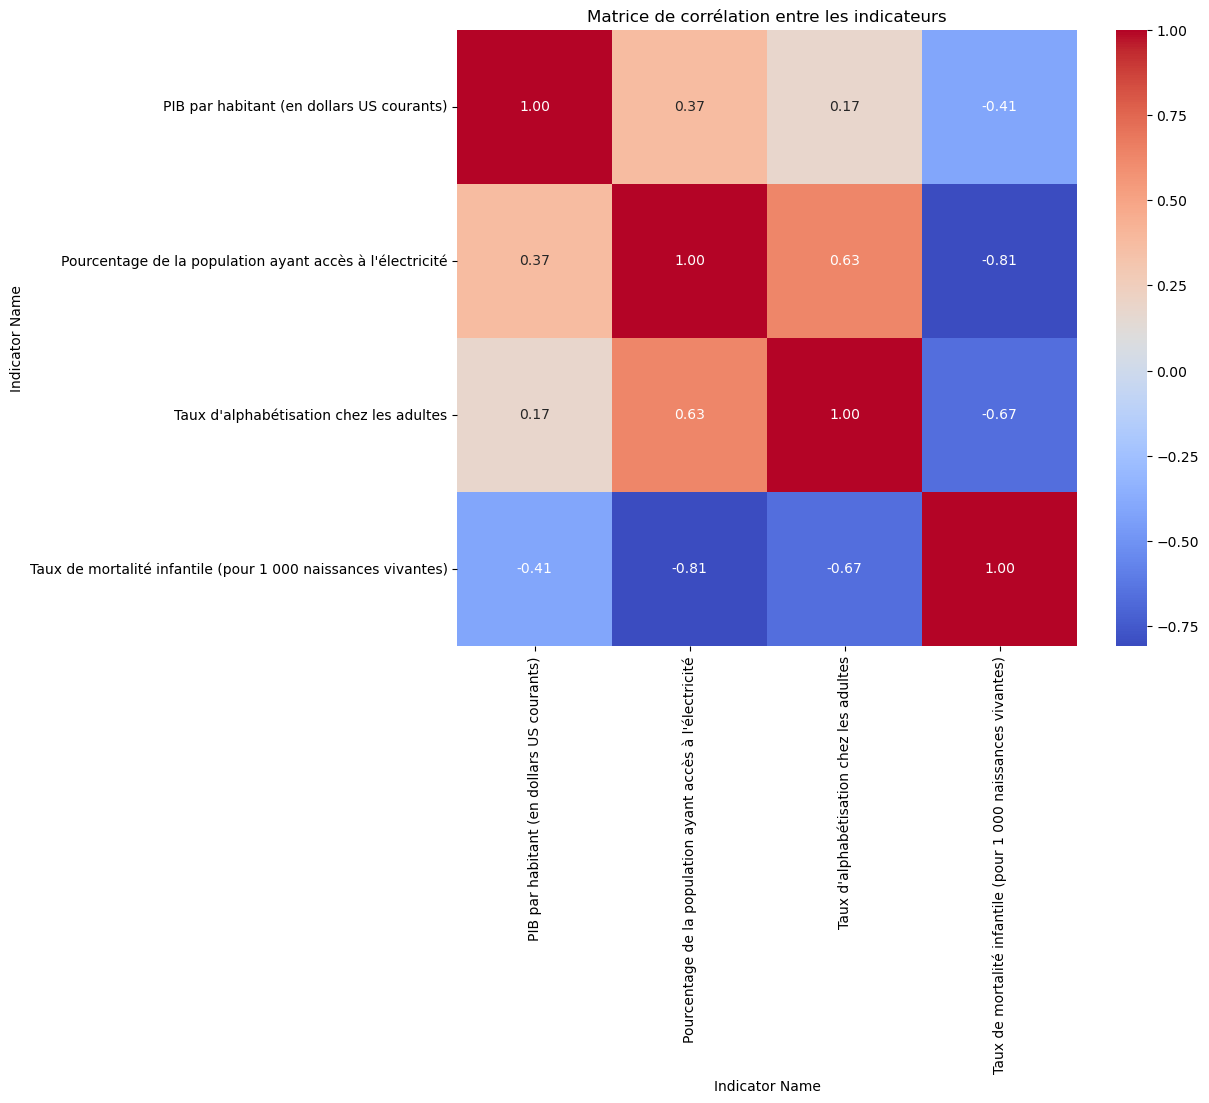

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculer la matrice de corrélation entre les indicateurs
indicator_columns = data_pivot.columns[3:]  # Indicateurs uniquement
correlation_matrix = data_pivot[indicator_columns].corr()

# Visualiser la matrice de corrélation avec une heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation entre les indicateurs")
plt.show()

La colonne 'Year' est valide et prête pour le regroupement.


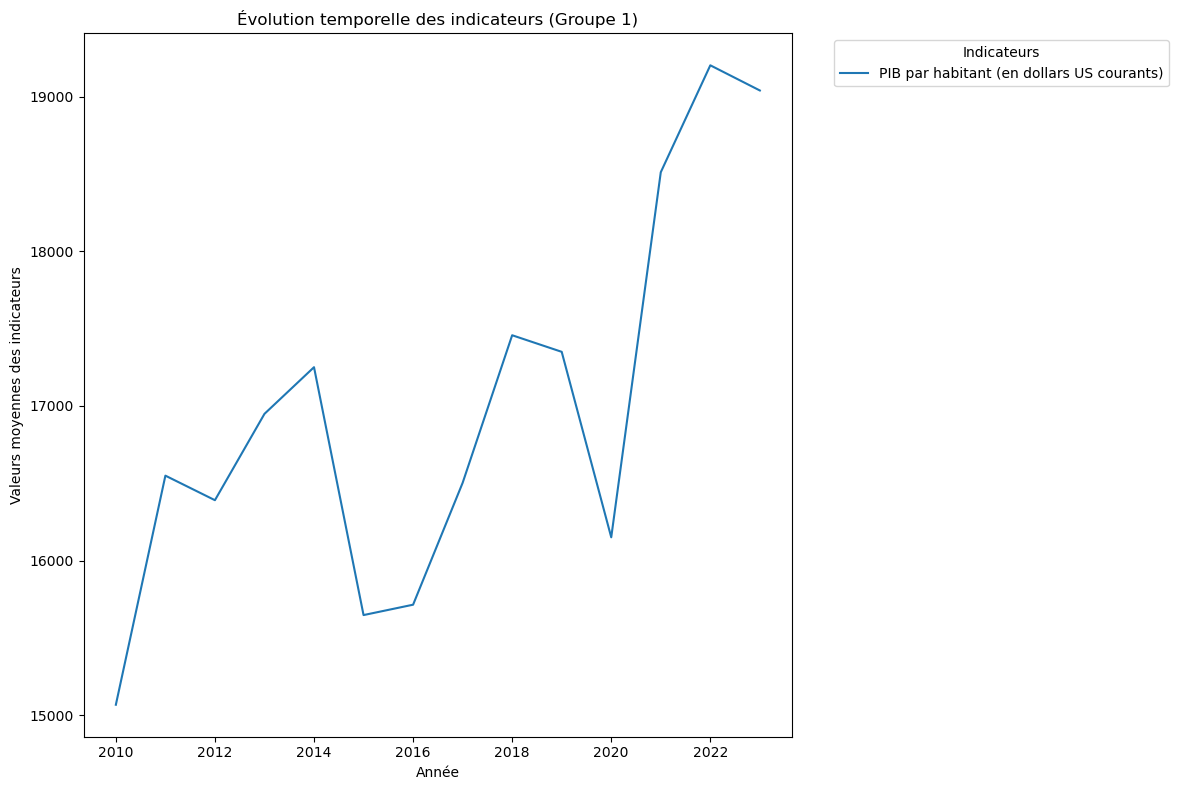

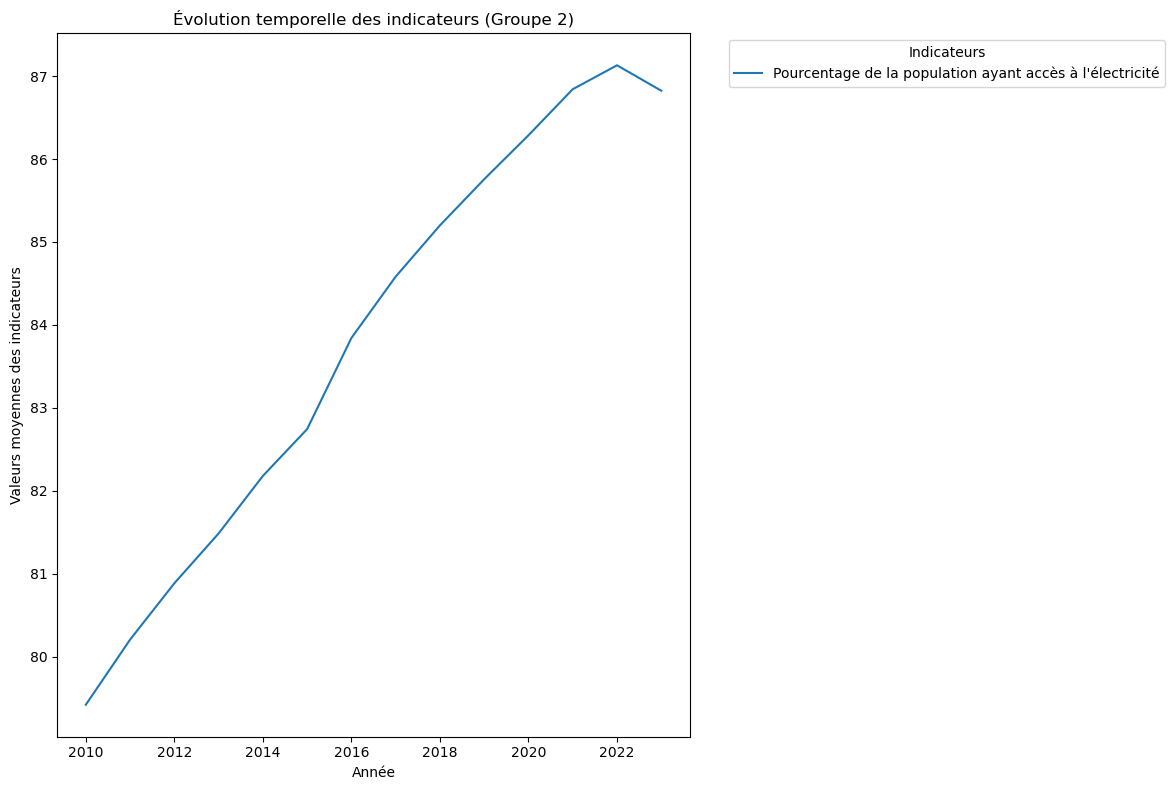

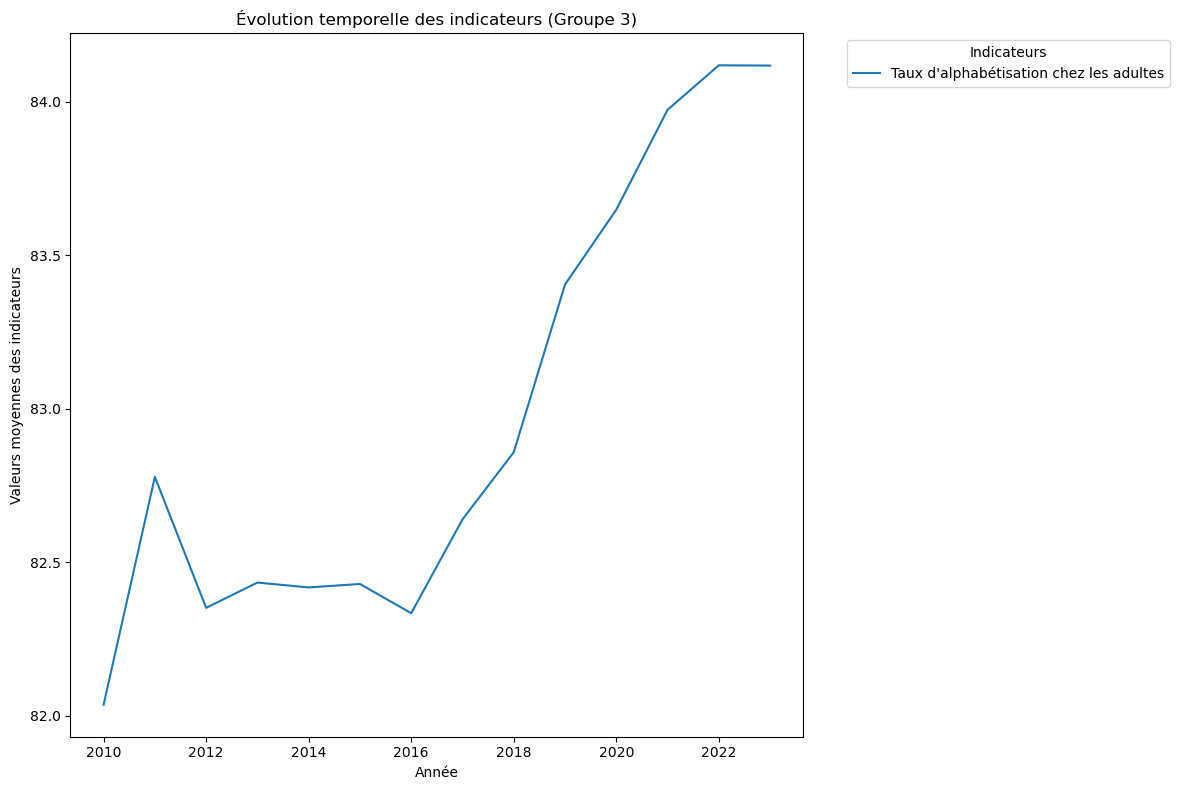

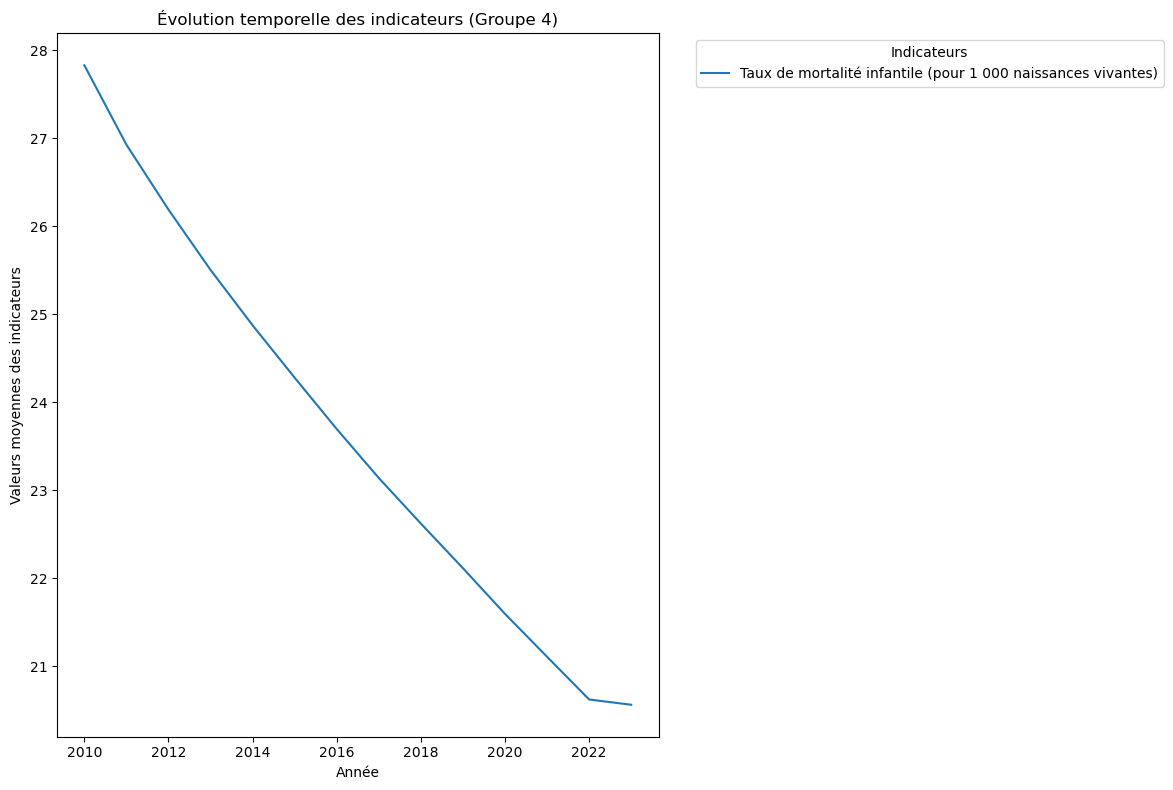

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Assurer que 'Year' est une colonne unidimensionnelle et de type numérique
data_pivot["Year"] = pd.to_numeric(data_pivot["Year"], errors="coerce")

# Supprimer les lignes où 'Year' est NaN
data_pivot = data_pivot.dropna(subset=["Year"])

# Vérifier que 'Year' est de type numérique et une colonne valide
if "Year" in data_pivot.columns and data_pivot["Year"].ndim == 1:
    print("La colonne 'Year' est valide et prête pour le regroupement.")
else:
    raise ValueError("La colonne 'Year' est toujours problématique.")

# Sélectionner uniquement les colonnes numériques pour les indicateurs
numeric_columns = data_pivot.select_dtypes(include=["number"]).columns.difference(["Year"])
data_numeric = data_pivot[["Year"] + list(numeric_columns)]

# Calculer la moyenne des indicateurs par année
indicators_by_year = data_numeric.groupby("Year").mean()

# Diviser les indicateurs en 4 groupes pour des visualisations séparées
indicator_groups = [
    numeric_columns[:len(numeric_columns) // 4],  # Premier quart
    numeric_columns[len(numeric_columns) // 4:len(numeric_columns) // 2],  # Deuxième quart
    numeric_columns[len(numeric_columns) // 2:3 * len(numeric_columns) // 4],  # Troisième quart
    numeric_columns[3 * len(numeric_columns) // 4:]  # Dernier quart
]

# Créer un graphique pour chaque groupe d'indicateurs
for i, group in enumerate(indicator_groups):
    plt.figure(figsize=(12, 8))
    for column in group:
        plt.plot(indicators_by_year.index, indicators_by_year[column], label=column)
    plt.title(f"Évolution temporelle des indicateurs (Groupe {i + 1})")
    plt.xlabel("Année")
    plt.ylabel("Valeurs moyennes des indicateurs")
    plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), title="Indicateurs")
    plt.tight_layout()
    plt.show()

In [27]:
# Dictionnaire manuel pour associer chaque région/pays à un continent
continent_mapping = {
    "Arab World": "Middle East and North Africa",
    "Africa Eastern and Southern": "Africa",
    "Africa Western and Central": "Africa",
    "World": "World",
    "North America": "North America",
    "South America": "South America",
    "Europe & Central Asia": "Europe and Central Asia",
    "East Asia & Pacific": "East Asia and Pacific",
    "Middle East & North Africa": "Middle East and North Africa",
    "Sub-Saharan Africa": "Africa",
    "South Asia": "South Asia",
    # Ajoutez d'autres mappings spécifiques si nécessaire
}

# Ajouter une colonne "Continent" ou "Region" en fonction du dictionnaire
data_pivot["Region"] = data_pivot["Country Name"].map(continent_mapping)

# Vérifier les données après ajout
print("Aperçu des données avec la colonne 'Region' :")
print(data_pivot[["Country Name", "Region"]].drop_duplicates().head())


Aperçu des données avec la colonne 'Region' :
Indicator Name                                   Country Name  \
0                                                  Arab World   
14                                                      World   
28                East Asia & Pacific (excluding high income)   
42              Europe & Central Asia (excluding high income)   
56                                                 South Asia   

Indicator Name                        Region  
0               Middle East and North Africa  
14                                     World  
28                                       NaN  
42                                       NaN  
56                                South Asia  


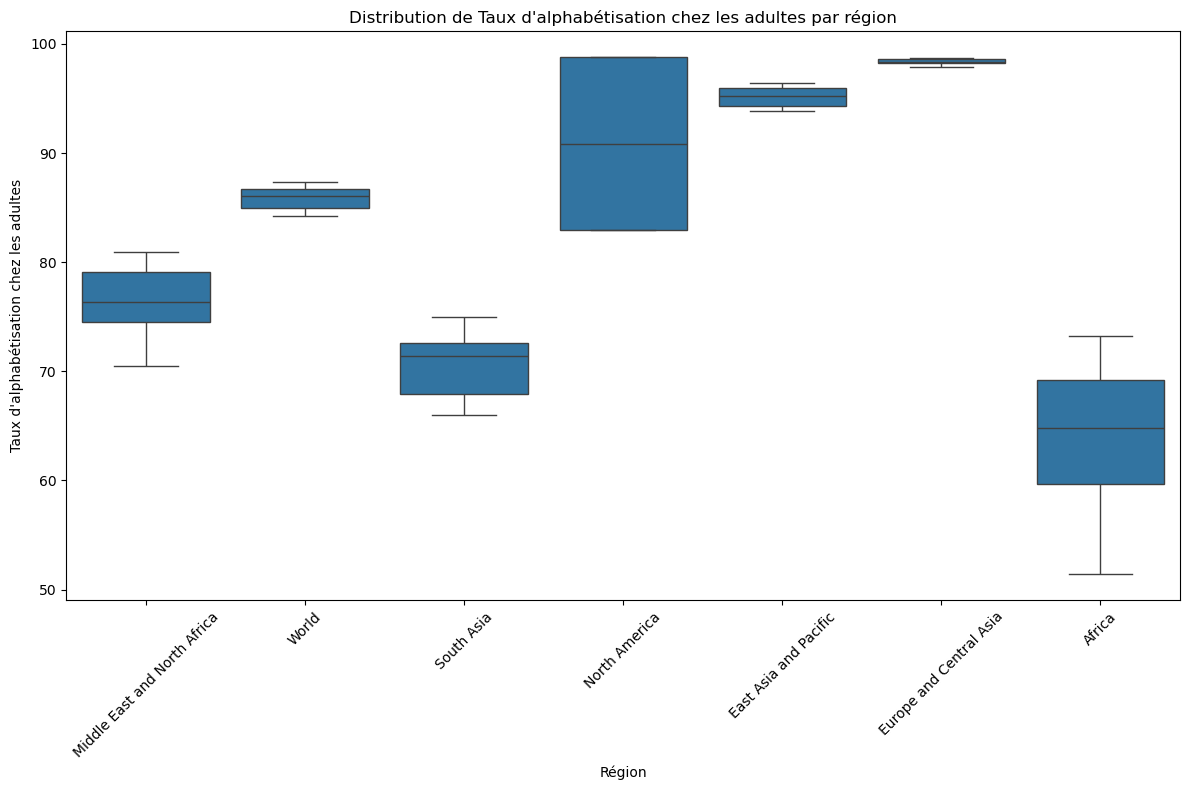

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Exemple d'indicateur à analyser
indicator_name = "Taux d'alphabétisation chez les adultes"

# Créer un boxplot pour l'indicateur par continent
plt.figure(figsize=(12, 8))
sns.boxplot(data=data_pivot, x="Region", y=indicator_name)
plt.title(f"Distribution de {indicator_name} par région")
plt.xlabel("Région")
plt.ylabel(indicator_name)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


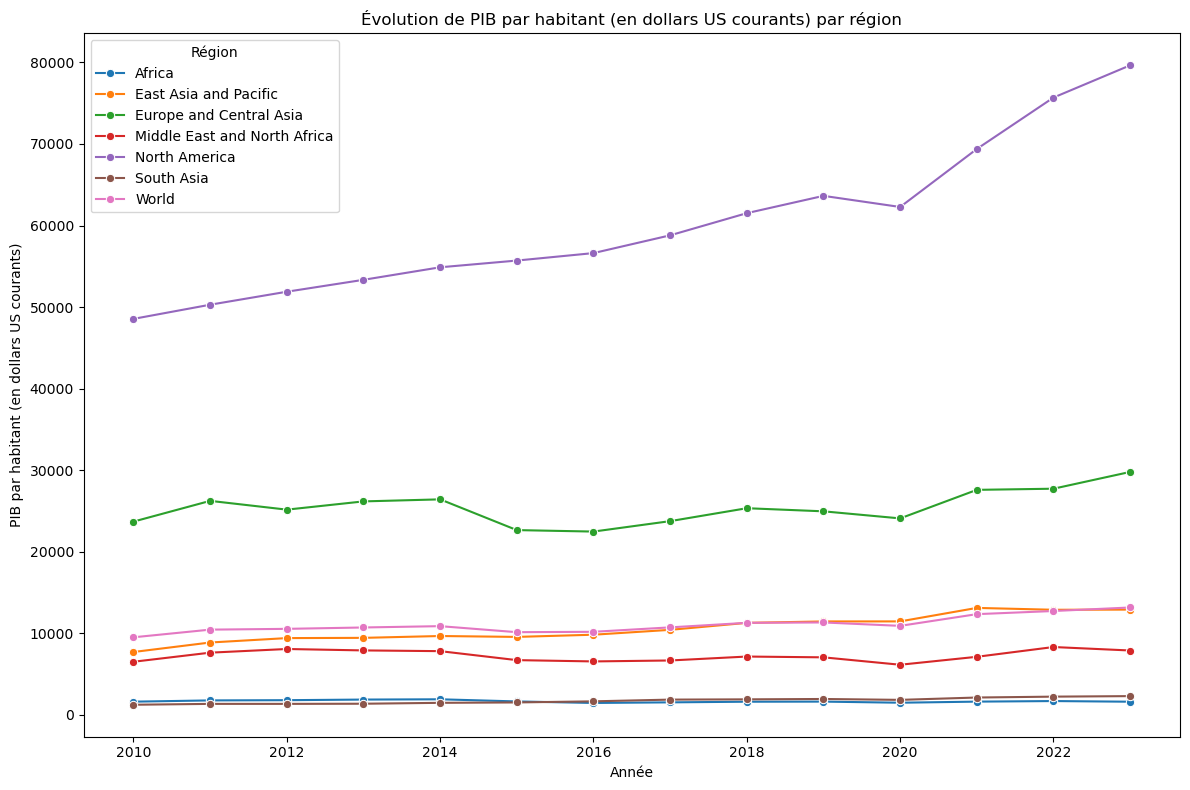

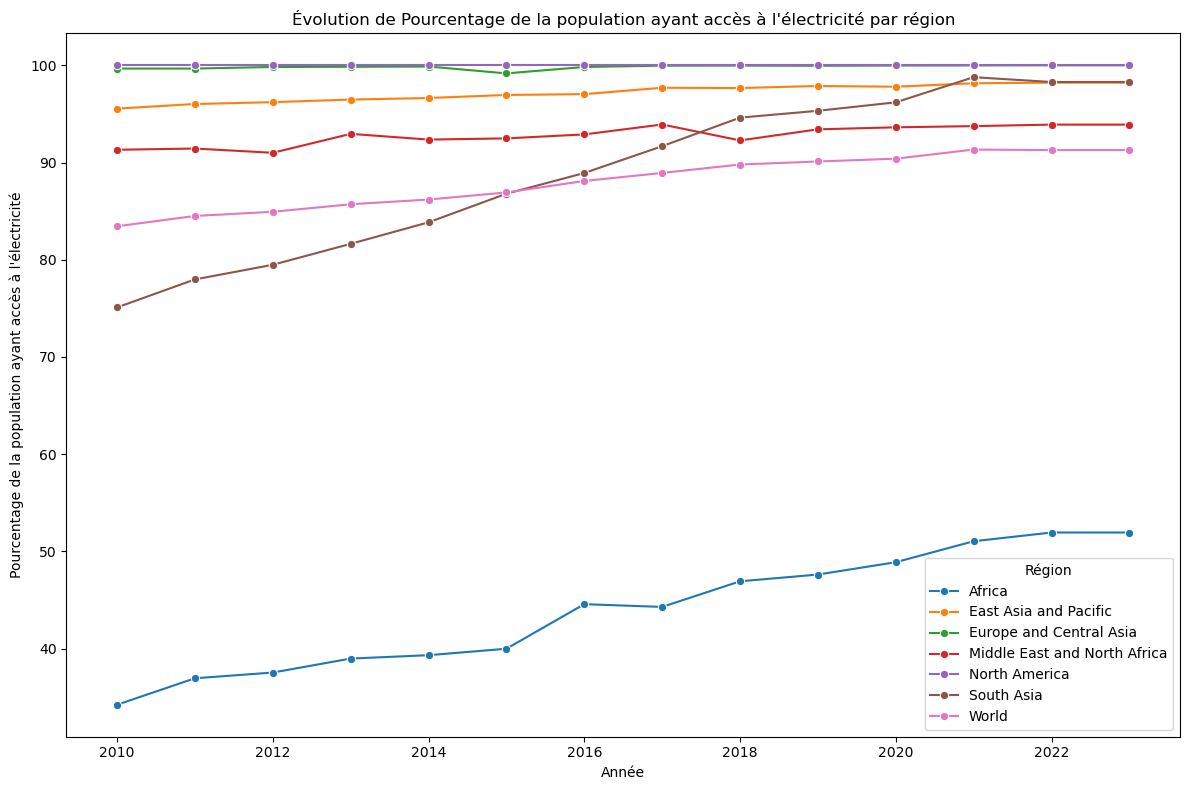

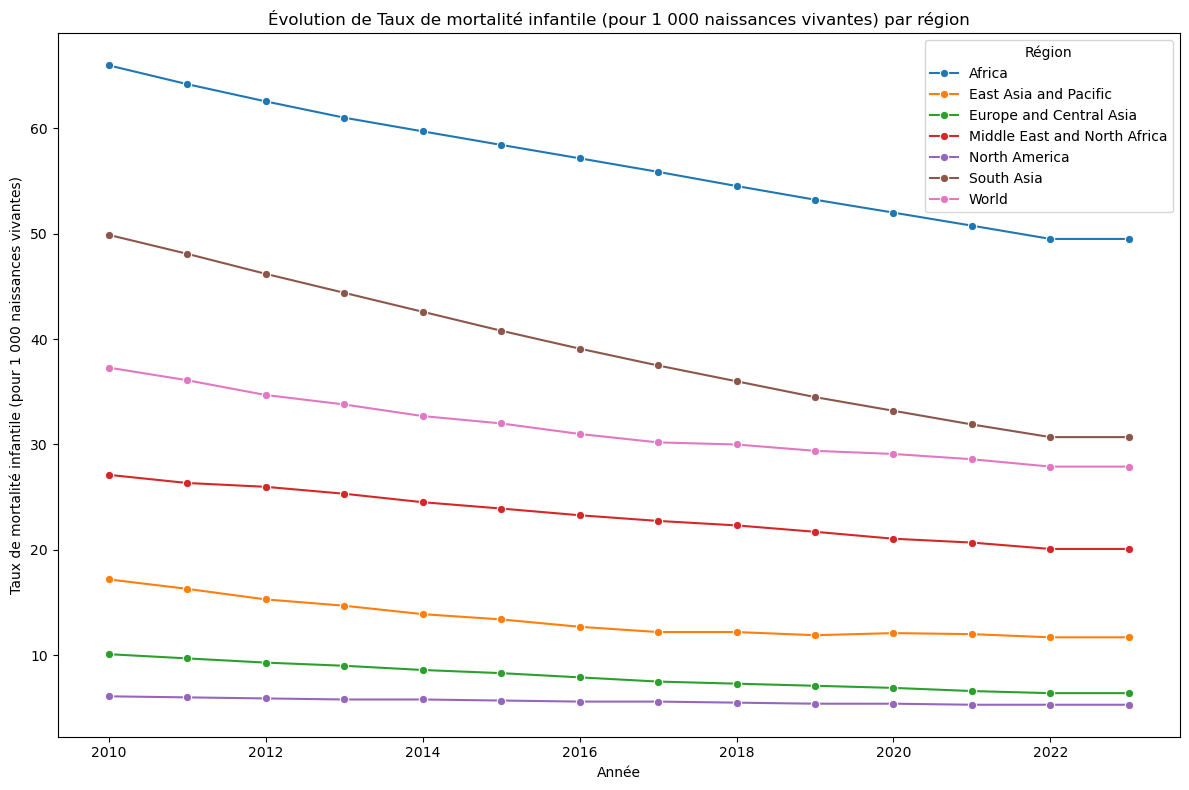

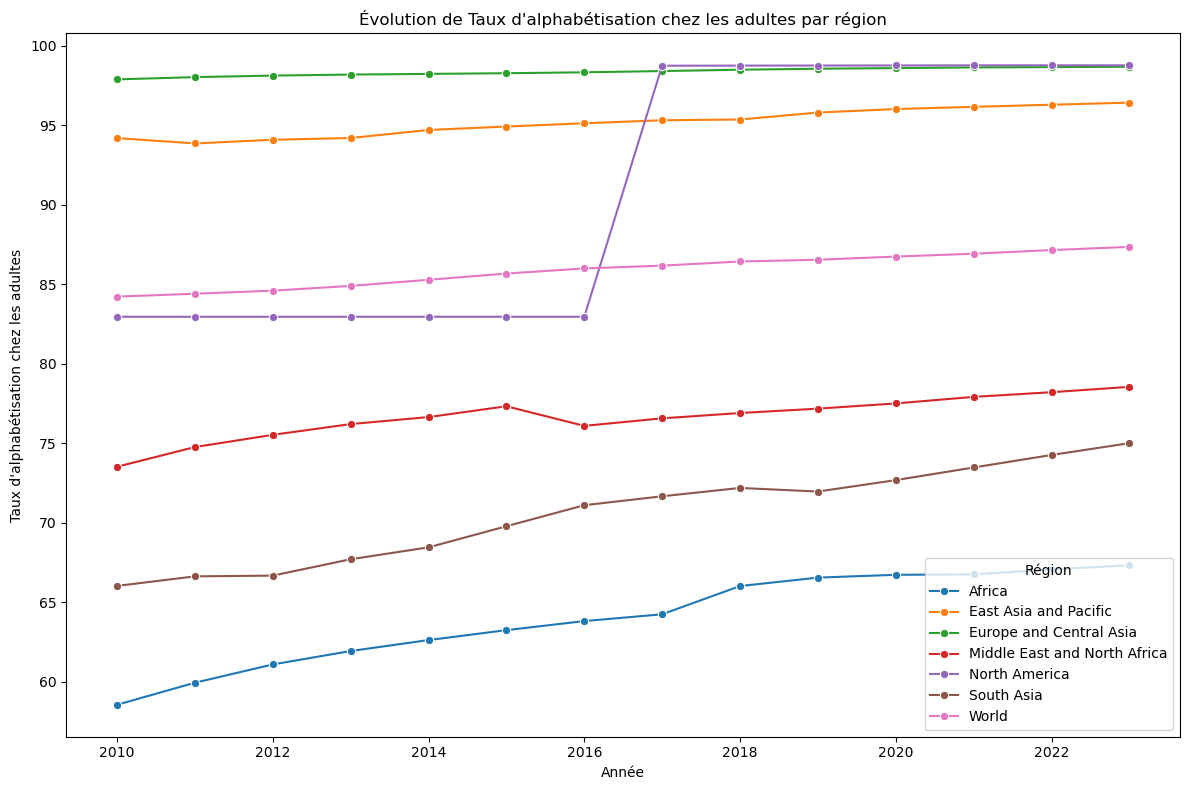

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner les colonnes des indicateurs uniquement
indicator_columns = [
    "PIB par habitant (en dollars US courants)",
    "Pourcentage de la population ayant accès à l'électricité",
    "Taux de mortalité infantile (pour 1 000 naissances vivantes)",
    "Taux d'alphabétisation chez les adultes"
]

# Boucler sur chaque indicateur pour tracer les tendances temporelles par région
for indicator_name in indicator_columns:
    # Calculer la moyenne par région et année pour l'indicateur
    indicator_by_region_year = data_pivot.groupby(["Region", "Year"])[indicator_name].mean().reset_index()
    
    # Tracer les tendances par région
    plt.figure(figsize=(12, 8))
    sns.lineplot(data=indicator_by_region_year, x="Year", y=indicator_name, hue="Region", marker="o")
    plt.title(f"Évolution de {indicator_name} par région")
    plt.xlabel("Année")
    plt.ylabel(indicator_name)
    plt.legend(title="Région")
    plt.tight_layout()
    plt.show()


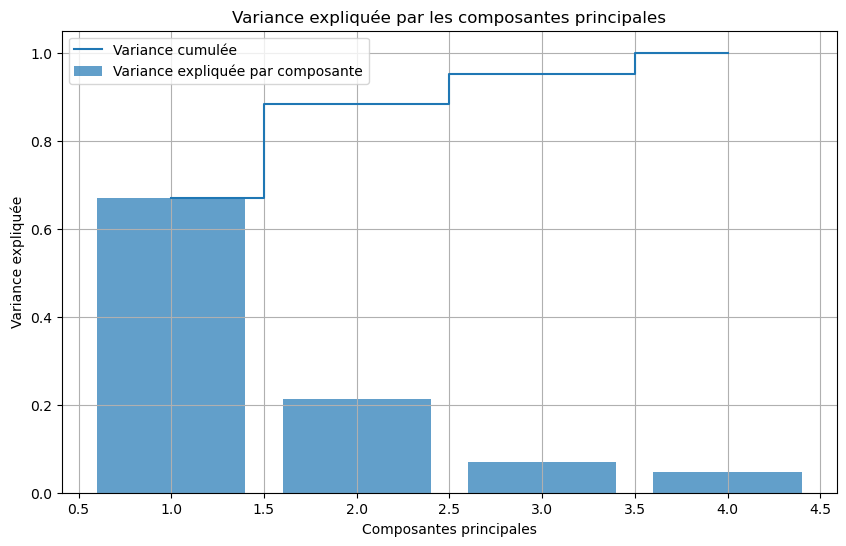

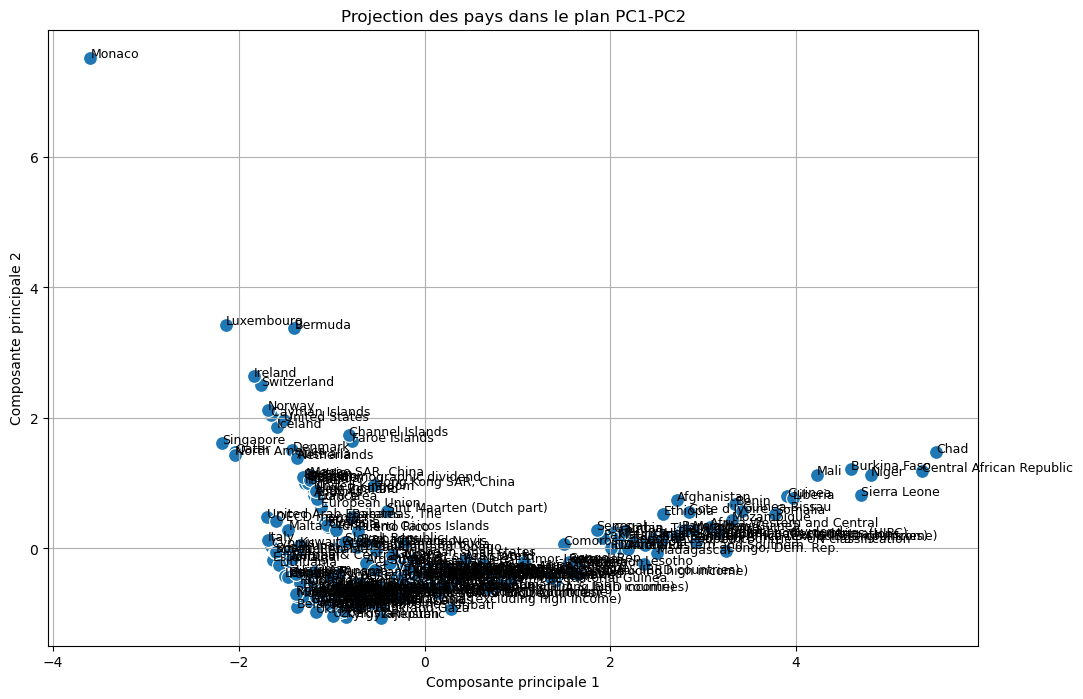

In [30]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Sélectionner uniquement les colonnes numériques pour l'ACP
numeric_columns = [
    "PIB par habitant (en dollars US courants)",
    "Pourcentage de la population ayant accès à l'électricité",
    "Taux de mortalité infantile (pour 1 000 naissances vivantes)",
    "Taux d'alphabétisation chez les adultes"
]

# Filtrer les données pour l'année la plus récente
latest_year = data_pivot["Year"].max()
data_acp = data_pivot[data_pivot["Year"] == latest_year][numeric_columns].dropna()

# Standardiser les données
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_acp)

# Réaliser l'ACP
pca = PCA()
pca_result = pca.fit_transform(data_scaled)

# Expliquer la variance cumulée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Afficher la variance expliquée par composante
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center',
        label='Variance expliquée par composante')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid',
         label='Variance cumulée')
plt.xlabel('Composantes principales')
plt.ylabel('Variance expliquée')
plt.title('Variance expliquée par les composantes principales')
plt.legend(loc='best')
plt.grid()
plt.show()

# Résultat des composantes principales (premières dimensions)
pca_df = pd.DataFrame(pca_result[:, :2], columns=["PC1", "PC2"])
pca_df["Country Name"] = data_pivot[data_pivot["Year"] == latest_year]["Country Name"].values

# Visualiser les pays dans le plan PC1-PC2
plt.figure(figsize=(12, 8))
sns.scatterplot(x="PC1", y="PC2", data=pca_df, s=100)
for i, country in enumerate(pca_df["Country Name"]):
    plt.text(pca_df.loc[i, "PC1"], pca_df.loc[i, "PC2"], country, fontsize=9)
plt.title("Projection des pays dans le plan PC1-PC2")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid()
plt.show()


Aperçu des données avant traitement :
Indicator Name  PIB par habitant (en dollars US courants)  \
13                                            7292.210408   
27                                           13169.598225   
41                                            9900.613565   
55                                            8548.010378   
69                                            2303.302910   

Indicator Name  Pourcentage de la population ayant accès à l'électricité  \
13                                                      90.654518          
27                                                      91.277853          
41                                                      98.029657          
55                                                      99.991598          
69                                                      98.284156          

Indicator Name  Taux de mortalité infantile (pour 1 000 naissances vivantes)  \
13                                                      23

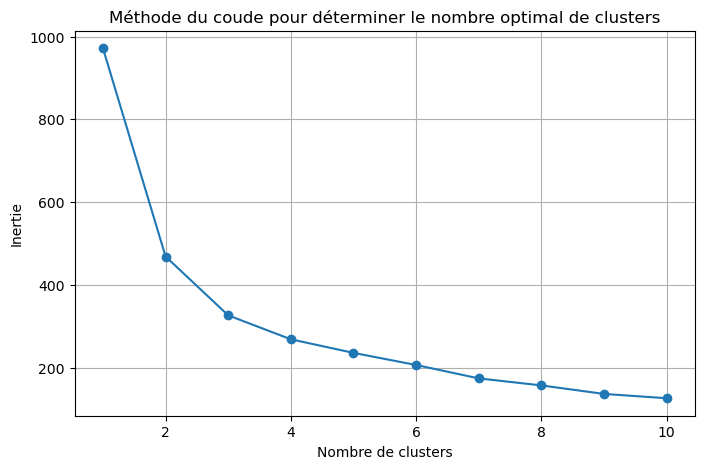

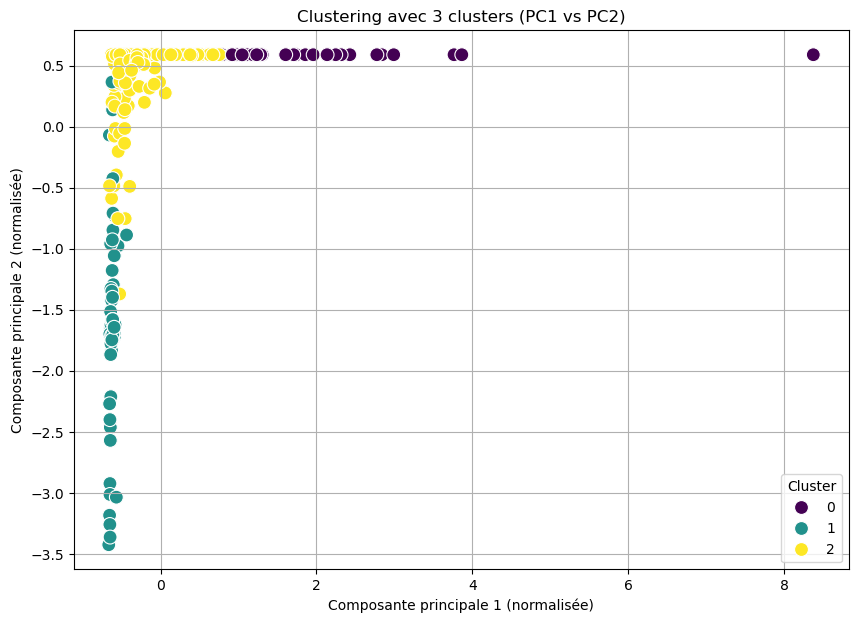

TypeError: agg function failed [how->mean,dtype->object]

In [31]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Étape 1 : Préparation des données
numeric_columns = [
    "PIB par habitant (en dollars US courants)",
    "Pourcentage de la population ayant accès à l'électricité",
    "Taux de mortalité infantile (pour 1 000 naissances vivantes)",
    "Taux d'alphabétisation chez les adultes"
]

# Filtrer pour l'année la plus récente
latest_year = data_pivot["Year"].max()
data_clustering = data_pivot[data_pivot["Year"] == latest_year][numeric_columns]

# Vérifier les types et le contenu des colonnes
print("Aperçu des données avant traitement :")
print(data_clustering.head())
print(data_clustering.dtypes)

# Convertir en numérique si nécessaire
data_clustering = data_clustering.apply(pd.to_numeric, errors="coerce")

# Supprimer les lignes contenant des NaN après conversion
data_clustering = data_clustering.dropna()

# Standardiser les données
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clustering)

# Étape 2 : Déterminer le nombre optimal de clusters (méthode du coude)
inertia = []
range_clusters = range(1, 11)

for k in range_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Visualiser la méthode du coude
plt.figure(figsize=(8, 5))
plt.plot(range_clusters, inertia, marker='o')
plt.title("Méthode du coude pour déterminer le nombre optimal de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.grid()
plt.show()

# Étape 3 : Appliquer KMeans avec un nombre de clusters choisi (ex. k=3)
optimal_k = 3  # Modifiez ce nombre après avoir analysé la méthode du coude
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Ajouter les clusters aux données
data_clustering_with_clusters = data_pivot[data_pivot["Year"] == latest_year].copy()
data_clustering_with_clusters["Cluster"] = clusters

# Étape 4 : Visualisation des clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=data_scaled[:, 0], y=data_scaled[:, 1], hue=clusters, palette="viridis", s=100
)
plt.title(f"Clustering avec {optimal_k} clusters (PC1 vs PC2)")
plt.xlabel("Composante principale 1 (normalisée)")
plt.ylabel("Composante principale 2 (normalisée)")
plt.legend(title="Cluster")
plt.grid()
plt.show()

# Étape 5 : Afficher un résumé des clusters
cluster_summary = data_clustering_with_clusters.groupby("Cluster").mean()
print("Résumé des clusters :")
print(cluster_summary)

